# Проектна задача по предметот Мобилна Роботика

# Ant-v5

`Ant-v5` е стандардна средина во `Gymnasium` базирана на физичкиот симулатор **MuJoCo**. Таа се користи за тестирање и развој на алгоритми за континуирана контрола (како што е предложено од Schulman et al. во трудот за GAE).

## Што е Ant?
Роботот е четириножна структура (квадрупед) која се состои од:
* **Торзо:** Централен дел (слободно ротирачко тело).
* **Нозе:** Четири нозе, каде секоја се состои од два дела поврзани со зглобови.
* **Физички спецификации:** И покрај името, роботот е висок **75cm** и тежи **910.88g** (торзо: 327.25g, секоја нога: 145.91g).



## Цел на задачата
Целта е агентот да научи да ги координира четирите нозе за да се движи напред (во десна насока), применувајќи вртежен момент на **8-те зглобови** (колк и колено на секоја нога).

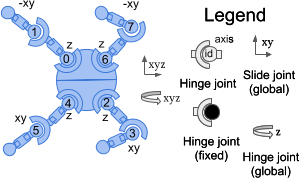

In [1]:
from PIL import Image
Image.open(r"C:/Users/User/Desktop/за елаборат/ant.png")

## Акционен простор (Action Space)
Просторот на акции е дефиниран како `Box(-1.0, 1.0, (8,), float32)`. Вредностите претставуваат нормализиран вртежен момент (torque) применет на секој зглоб.

| Индекс | Опис на акција | Име  | Тип (Единица) |
|:---|:---|:---|:---|
| 0 | Вртежен момент: заден десен колк | `hip_4` | hinge (N m) |
| 1 | Вртежен момент: заден десен агол | `angle_4` | hinge (N m) |
| 2 | Вртежен момент: преден лев колк | `hip_1` | hinge (N m) |
| 3 | Вртежен момент: преден лев агол | `angle_1` | hinge (N m) |
| 4 | Вртежен момент: преден десен колк | `hip_2` | hinge (N m) |
| 5 | Вртежен момент: преден десен агол | `angle_2` | hinge (N m) |
| 6 | Вртежен момент: заден лев колк | `hip_3` | hinge (N m) |
| 7 | Вртежен момент: заден лев агол | `angle_3` | hinge (N m) |

> **Забелешка:** Вредностите се движат од -1 до 1, што одговара на максималниот капацитет на моторите.

## Опсервациски простор (Observation Space)
Стандардната големина на опсервацијата е вектор со **105 елементи** (`Box(-inf, inf, (105,), float64)`). Опсервацијата ги содржи:

1. **qpos (13 елементи):** Позиции на деловите од телото.
2. **qvel (14 елементи):** Брзини (деривати на позициите).
3. **cfrc_ext (78 елементи):** Надворешни сили врз основа на центарот на маса (nbody * 6).

| Индекс | Опис на опсервација | Тип (Единица) |
|:---|:---|:---|
| 0 | z-координата на торзото | position (m) |
| 1-4 | Ориентација на торзото (кватернион) | angle (rad) |
| 5-12 | Агли на 8-те зглобови | angle (rad) |
| 13-15 | Линеарна брзина на торзото (x, y, z) | velocity (m/s) |
| 16-18 | Аголна брзина на торзото (x, y, z) | angular velocity (rad/s) |
| 19-26 | Брзини на зглобовите | angular velocity (rad/s) |

# Soft Actor-Critic (SAC)

Soft Actor-Critic (SAC) е модерен алгоритам за *Reinforcement Learning* наменет за задачи со континуирани акции. Алгоритамот е предложен од Haarnoja и соработниците и денес претставува еден од најуспешните пристапи за роботска контрола, локомоција и манипулација.

За разлика од класичните алгоритми, SAC комбинира висока стабилност на учење, добра искористеност на податоците и ефикасно истражување на околината. Поради овие карактеристики, тој често се користи како референтен алгоритам за задачи со континуирана контрола, вклучувајќи ја и MuJoCo Ant средината.

## Зошто е избран SAC?

Во задачата Ant агентот треба истовремено да контролира осум зглобови и да научи стабилно движење користејќи континуирани акции. Ова претставува сложен проблем кој бара алгоритам способен да работи со високо-димензионален простор на акции.

SAC е избран поради следните причини:

- Поддржува континуирани акции.
- Обезбедува стабилно тренирање на сложени роботски системи.
- Ефикасно ги користи претходно собраните искуства.
- Постигнува добра рамнотежа помеѓу истражување и искористување на наученото знаење.
- Покажува одлични резултати во задачи поврзани со локомоција и контрола на роботи.

Овие карактеристики го прават SAC соодветен избор за учење на движењето на виртуелната мравка.

## Примена на SAC во Ant средината

Во овој проект SAC алгоритамот се користи за тренирање на агент кој треба да научи стабилно и ефикасно движење во MuJoCo Ant средината.

Агентот добива награди за:

- Движење нанапред.
- Одржување на соодветна висина.
- Стабилна ориентација на телото.
- Рамномерно користење на сите нозе.

Истовремено добива казни за:

- Паѓање.
- Мирување подолг временски период.
- Прекумерна потрошувачка на енергија.
- Нагли и нестабилни движења.

Со комбинација на SAC, Replay Buffer и прилагодена reward функција, агентот постепено учи да развие стабилен и енергетски ефикасен модел на движење кој му овозможува успешно движење низ околината.

# Детално разгледување на алгоритмот Soft Actor-Critic (SAC)

Soft Actor-Critic го воведува концептот на **ентрописка регуларизација** во RL. Наместо само да ја максимизира очекуваната награда, агентот ја максимизира очекуваната награда плус ентропијата на неговата полиса. Оваа ентропија ја мери "случајноста" на акциите на агентот.

## Дефиниција за Ентропија
Ентропијата $H$ ни кажува колку е случајна една случајна променлива. Колку е порамномерна веројатносната дистрибуција, толку е поголема ентропијата.

За случајна променлива $x$ со веројатносна функција $P$, ентропијата $H$ се пресметува според следната формула:

$$H(P) = \mathbb{E}_{x \sim P} [-\log P(x)]$$

Оваа математичка дефиниција служи како основа за разбирање на "бонус" наградите кои SAC ги користи за да го поттикне истражувањето.

Во SAC, стандардната функција V, која се користи за вреднување на состојбата (пандан на Q- табела, истата функција ја има) е променета за да вклучи ентрописки бонуси од секој временски чекор. Коефициентот $\alpha > 0$ го контролира балансот помеѓу максимизирање на наградата и максимизирање на ентропијата.

$$V^{\pi}(s) = \mathbb{E}_{\tau \sim \pi} \left[ \sum_{t=0}^{\infty} \gamma^t (R(s_t, a_t, s_{t+1}) + \alpha H (\pi(\cdot|s_t))) \mid s_0 = s \right]$$

Слично на $V^{\pi}$, функцијата $Q^{\pi}$ исто така се менува. Клучната разлика е во тоа што $Q^{\pi}$ ги вклучува ентрописките бонуси од сите временски чекори **освен првиот**:

$$Q^{\pi}(s, a) = \mathbb{E}_{\tau \sim \pi} \left[ \sum_{t=0}^{\infty} \gamma^t R(s_t, a_t, s_{t+1}) + \alpha \sum_{t=1}^{\infty} \gamma^t H (\pi(\cdot|s_t)) \mid s_0 = s, a_0 = a \right]$$

Со овие дефиниции, функција на состојбата ($V^{\pi}$) и функција на акцијата ($Q^{\pi}$) се поврзани преку следната релација:

$$V^{\pi}(s) = \mathbb{E}_{a \sim \pi} [Q^{\pi}(s, a)] + \alpha H (\pi(\cdot|s))$$



## Белманова равенка за SAC
Во ентрописки-регуларизираниот амбиент, Белманова равенката за функцијата на $Q^{\pi}$

$$Q^{\pi}(s, a) = \mathbb{E}_{\substack{s' \sim P \\ a' \sim \pi}} [R(s, a, s') + \gamma (Q^{\pi}(s', a') + \alpha H (\pi(\cdot|s'))))]$$

Ова се поедноставува до:

$$Q^{\pi}(s, a) = \mathbb{E}_{s' \sim P} [R(s, a, s') + \gamma V^{\pi}(s')]$$

## Како SAC учи во пракса?
SAC ефикасно учи паралелно две работи:
1. **Полиса ($\pi_{\theta}$):** Стратегијата на агентот.
2. **Две Q-функции ($Q_{\phi_1}, Q_{\phi_2}$):** За да се намали оптимистичката пристрасност при проценка на вредностите (clipped double-Q trick).

### Варијанти на SAC:
* **Со фиксен коефициент ($\alpha$):** Поедноставна за имплементација.
* **Со ентрописко ограничување:** Варијанта каде $\alpha$ се менува во текот на тренингот. Ова е верзијата која е попосакувана во професионалната пракса.

## Пресметување на целта (Target)
За да се стабилизира учењето и да се избегне оптимистичка пристрасност при проценка на вредностите, SAC го користи **clipped double-Q трикот**.

* **Метод:** Се користат две Q-мрежи ($Q_{\phi_1}$ и $Q_{\phi_2}$).
* **Пресметка:** За backup на целта се зема **минимумот** од вредностите предвидени од двете Q-мрежи.

## Loss функција за Q-мрежите
Конечно, loss функцијата за секоја од Q-мрежите ($L(\phi_i, \mathcal{D})$) се дефинира како средноквадратна грешка (Mean Squared Bellman Error - MSBE) помеѓу предвидувањето на мрежата и пресметаната целна вредност ($y$):

$$L(\phi_i, \mathcal{D}) = \mathbb{E}_{(s,a,r,s',d) \sim \mathcal{D}} \left[ \left( Q_{\phi_i}(s, a) - y(r, s', d) \right)^2 \right]$$

Оваа функција ги оптимизира параметрите $\phi_i$ за мрежата да биде што попрецизна во проценката на "soft" вредноста на акциите.

## Целна вредност (Target) во SAC
Целната вредност $y$ што ја користиме за да ги обучиме Q-мрежите ја комбинира сегашната награда со дисконтираната иднина, вклучувајќи го и ентропискиот бонус:

$$y(r, s', d) = r + \gamma(1 - d) \left( \min_{j=1,2} Q_{\phi_{targ,j}}(s', \tilde{a}') - \alpha \log \pi_{\theta}(\tilde{a}'|s') \right)$$

каде $\tilde{a}' \sim \pi_{\theta}(\cdot|s')$. Оваа равенка го користи „clipped double-Q“ трикот со земање на минимумот од двете Q-целни мрежи.

## Учење на Полисата (Learning the Policy)
Агентот ја оптимизира својата полиса за да ја максимизира очекуваната идна награда и ентропијата истовремено, односно го максимизира $V^{\pi}(s)$:

$$V^{\pi}(s) = \mathbb{E}_{a \sim \pi} [Q^{\pi}(s, a) - \alpha \log \pi(a|s)]$$

Оваа математичка рамка му овозможува на агентот да балансира меѓу експлоатацијата на веќе наученото и истражувањето на нови простори.

## Репараметризација
За да го направиме овој процес диференцијабилен (што е неопходно за невронските мрежи), го користиме **трикот на репараметризација**. 

Наместо директно земање примерок од полисата $\pi_{\theta}(\cdot|s)$, ја изразуваме акцијата како детерминистичка функција:

$$\tilde{a}_{\theta}(s, \xi) = \tanh(\mu_{\theta}(s) + \sigma_{\theta}(s) \odot \xi), \quad \xi \sim \mathcal{N}(0, 1)$$

Ова овозможува градиентот да помине низ функцијата за акции, што е клучно за стабилизирање на учењето кај squashed Gaussian полисите.

## 1. Справување со физичките ограничувања
Во SAC ја користиме **tanh** функцијата (squashing function). Ова е клучно за роботиката бидејќи:

* Го ограничува излезот на моторите во интервал од `[-1, 1]`.
* Го спречува експлодирањето на акциите.
* Ја менува дистрибуцијата на веројатност во нешто покомплексно од обична Гаусова крива, што е поприродно за сложени движења.

## 2. Адаптивна несигурност
Во старите методи, „колку случајно да биде движењето“ беше фиксен број. Во SAC, невронската мрежа сама одредува колку да биде несигурна:

* Мрежата ги дава и `mean` (каде да се движи) и `std dev` (колку да ризикува).
* Ако роботот е во непозната ситуација, `std dev` ќе биде голема (повеќе истражување).
* Ако роботот е во позната ситуација, `std dev` ќе биде мала (прецизно извршување).

## 4. Финална цел на Акторот
Акторот бара такви параметри $\theta$ кои ја максимизираат оваа вредност:

$$\max_{\theta} \mathbb{E}_{s \sim \mathcal{D}, \xi \sim \mathcal{N}} \left[ \min_{j=1,2} Q_{\phi_j}(s, \tilde{a}_{\theta}(s, \xi)) - \alpha \log \pi_{\theta}(\tilde{a}_{\theta}(s, \xi)|s) \right]$$



* **Min-double-Q:** Ја користиме попесимистичката вредност од двете Q-мрежи за да избегнеме претерување.
* **Entropy term:** Ја одземаме логаритмската веројатност, што е еквивалентно на додавање ентрописки бонус.

## Како работи заедно?
1.  **Критичарите** ја градат „мапата“ (Q-values) со Белмановата равенка.
2.  **Акторот** ја користи таа мапа и се движи кон највисоките точки.
3.  **Ентропијата** го турка Акторот да не се „залепи“ на првата височина што ќе ја најде, туку да продолжи да бара подобар пат.

# Функција на награда (Reward Function) — целосно математичко и техничко објаснување

**Датотека:** `ant_reward_env.py`
**Класа:** `AntCustomRewardEnv` (наследува `gym.Wrapper`)
**Опкружување:** MuJoCo `Ant-v5`
**Цел на документот:** прецизна математичка формулација на функцијата на награда, точна локација во кодот каде секој член се пресметува, и образложение зошто секој член е избран.

---

---

## 1. Општ преглед и нотација

Функцијата на награда е **линеарна комбинација** од 10 членови (3 позитивни поттици + 7 казни), пресметана на секој временски чекор $t$ во методот `AntCustomRewardEnv.step()`. Секој член има своја тежина $w_k$, а тежините не се фиксни — тие се менуваат за време на тренингот преку **curriculum распоред** дефиниран во `train.py` (класата `CurriculumCallback` и функцијата `interpolate_weights`).

Општа форма:

$$
R_t = \sum_{k \in \text{поттици}} w_k \cdot r^k_t \;-\; \sum_{k \in \text{казни}} w_k \cdot p^k_t
$$

Сите тежини $w_k$ доаѓаат од речникот `self.weights` (иницијализиран од `DEFAULT_WEIGHTS`, презапишани преку `set_reward_weights()`).

---

## 2. Величини од состојбата

Пред да ги дефинираме членовите, ги воведуваме основните величини што се читаат/пресметуваат во секој чекор:

| Симбол | Опис | Извор во кодот |
|---|---|---|
| $\mathbf{p}_t = (x_t, y_t)$ | xy-позиција на торзото | `data.qpos[0:2]` |
| $z_t$ | висина на торзото | `data.qpos[2]` |
| $q_t = (w,x,y,z)$ | кватернион на торзото | `data.xquat[self._torso_id]` |
| $(\phi_t,\theta_t,\psi_t)$ | (roll, pitch, yaw) во радијани | `_quat_to_euler(quat)` |
| $\mathbf{a}_t \in \mathbb{R}^8$ | акција (моменти на 8 актуатори) | аргумент `action` во `step()` |
| $\mathbf{q}_t \in \mathbb{R}^8$ | позиции на зглобовите | `data.qpos[7:15]` |
| $\dot{\mathbf{q}}_t \in \mathbb{R}^8$ | брзини на зглобовите | `data.qvel[6:14]` |
| $\hat{\mathbf{d}}$ | единечна насока-цел | `self.target_direction` |
| $\phi_{ref}$ | референтен yaw | `self.phi_ref` |
| $dt$ | временски чекор на симулацијата | `self.unwrapped.dt` |

Хелпер-функциите:

```python
def _quat_to_euler(quat_wxyz): ...   # кватернион -> (roll, pitch, yaw)
def _angle_diff(a, b): ...            # разлика меѓу агли, завиткана во [-pi, pi]
```
им претходат на класата во истата датотека и се повикуваат внатре во `step()`.

---

## 3. Членови на наградата 

### 3.1 Брзина

**Каде во кодот:**
```python
velocity_xy = (xy - self._prev_xy) / dt
r_vel = float(np.dot(velocity_xy, self.target_direction))
speed = float(np.linalg.norm(velocity_xy))
self._vel_history.append(r_vel)
self._speed_history.append(speed)
r_avg_vel = float(np.mean(self._vel_history))
r_survival = 1.0
```

**Математика:**

$$\mathbf{v}_t = \frac{\mathbf{p}_t - \mathbf{p}_{t-1}}{dt}$$

$$r^{vel}_t = \mathbf{v}_t \cdot \hat{\mathbf{d}} \qquad\qquad s_t = \lVert \mathbf{v}_t \rVert_2$$

$$r^{avgvel}_t = \frac{1}{N}\sum_{k=t-N+1}^{t} r^{vel}_k, \qquad N = \texttt{avg\_vel\_window} = 25$$

$$r^{surv}_t = 1$$

**Зошто е избрано:**
- $r^{vel}_t$ е **главниот поттик за задачата** — движење во посакуваната насока (проекција на брзината врз $\hat{\mathbf{d}}$, а не само интензитет, за да не се "исплати" движење во погрешна насока).
- $r^{avgvel}_t$ е изгладена (лизгачки прозорец, `deque` со `maxlen=25`) верзија на истиот сигнал. Моменталната брзина по чекор природно осцилира со фазата на одот (ногата туку што допрела до подот наспроти веднаш пред отскок), па сурова моментална брзина би внела шум во градиентот. Просечувањето дава постабилен, помалку шумовит сигнал за учење.
- $r^{surv}_t=1$ е мала константна награда по чекор во живот — обично стандардна пракса во RL за роботика за да се обесхрабри "самоубиствено" рано завршување на епизодата кога казните привремено надвладуваат.
- $s_t$ (интензитет на брзина) **не влегува директно** во наградата — се користи само за детекција на застој (види 3.10).

---

### 3.2 Ориентација

**Каде во кодот:**
```python
quat = data.xquat[self._torso_id].copy()
roll, pitch, yaw = _quat_to_euler(quat)
yaw_err = _angle_diff(yaw, self.phi_ref)
p_orientation = yaw_err**2 + roll**2 + pitch**2
uprightness = np.cos(roll) * np.cos(pitch)
```

**Математика:**

$$e^{yaw}_t = \big((\psi_t - \phi_{ref}) + \pi \bmod 2\pi\big) - \pi$$

$$p^{orient}_t = (e^{yaw}_t)^2 + \phi_t^2 + \theta_t^2$$

$$u_t = \cos(\phi_t)\cos(\theta_t)$$

**Зошто е избрано:**
- Без казна за yaw грешка, мравката може да се движи во точната насока додека е свртена странично или наназад — механички чудно и нестабилно за подолгорочен од. Разликата се "завиткува" во $[-\pi,\pi]$ (`_angle_diff`) за да се избегне лажен голем скок при премин преку границата $\pm\pi$ (пр. $179°$ наспроти $-179°$ треба да бидат речиси еднакви, не разлика од скоро $360°$).
- $\phi_t^2+\theta_t^2$ (roll² + pitch²) казнува накривување настрана/напред-назад — дополнителна стабилизациска компонента.
- $u_t$ (исправеност) не влегува директно во наградата тука, туку се **пресметува еднаш и се повторно користи** во детекцијата на паѓање (3.9) — избегнува дуплирање на пресметка.

---

### 3.3 Висина

**Каде во кодот:**
```python
z = data.qpos[2]
p_height = (z - self.height_target) ** 2
```

**Математика:**

$$p^{height}_t = (z_t - z_{target})^2, \qquad z_{target} = \tfrac{1}{2}(z_{min}+z_{max})$$

**Зошто е избрано:**
Без ова, SAC може да открие "евтин" начин да ги минимизира другите казни (енергија, joint velocity) со легнување на телото на подот или екстремно кревање нагоре. Квадратната казна ја таргетира конкретна референтна висина (стандардно средината на "здравиот" z-опсег на моделот), спречувајќи ги двата екстрема.

---

### 3.4 Енергија

**Каде во кодот:**
```python
p_energy = float(np.mean(np.square(action)))
```

**Математика:**

$$p^{energy}_t = \frac{1}{8}\sum_{i=1}^{8} a_{t,i}^2$$

**Зошто е избрано:**
Стандардна регулаторска (energy-cost) казна во RL контрола на роботи. Без неа, политиката нема причина да избегнува максимални, нагли моменти на секој актуатор — резултат е обично трескава, енергетски нереална контрола. Во v2 е сменето од `sum` во `mean` (споредено со v1) за да не доминира нумерички над другите нормализирани членови откако тежината му расте преку curriculum.

---

### 3.5 Гранични вредности на зглобовите

**Каде во кодот:**
```python
joint_qpos = data.qpos[ACTUATED_QPOS_START:ACTUATED_QPOS_END]
lo = self._joint_ranges[:, 0]
hi = self._joint_ranges[:, 1]
span = np.clip(hi - lo, 1e-6, None)
dist_to_lo = (joint_qpos - lo) / span
dist_to_hi = (hi - joint_qpos) / span
closeness = 1.0 - np.clip(np.minimum(dist_to_lo, dist_to_hi), 0.0, 1.0)
p_joint_limit = float(np.mean(closeness**2))
```

**Математика:** за секој зглоб $i\in\{1,\dots,8\}$ со опсег $[lo_i,hi_i]$ и $\text{span}_i=\max(hi_i-lo_i,10^{-6})$:

$$d^{lo}_{t,i} = \frac{q_{t,i}-lo_i}{\text{span}_i}, \qquad d^{hi}_{t,i} = \frac{hi_i-q_{t,i}}{\text{span}_i}$$

$$c_{t,i} = 1 - \operatorname{clip}\big(\min(d^{lo}_{t,i},d^{hi}_{t,i}),\,0,\,1\big)$$

$$p^{jlimit}_t = \frac{1}{8}\sum_{i=1}^{8} c_{t,i}^2$$

Забелешка: $c_{t,i}\to 1$ кога зглобот $i$ е точно на или преку границата; $c_{t,i}\to 0$ кога е во средината на својот опсег.

**Зошто е избрано:**
Механичките зглобови имаат физички гранични агли. Притискање до крајната граница честопати резултира во нестабилни, "закочени", нереалистични пози (и е механички штетно на реален робот). Оваа "мека" (soft) казна постепено ги обесхрабрува екстремните агли без тврдо да ги забранува — за разлика од тврд clip што би можел нагло да ја "скрши" continuity на градиентот.

---

### 3.6 Брзина на зглобовите

**Каде во кодот:**
```python
joint_qvel = data.qvel[6:14]  # 6 free-joint dof, then 8 actuated dof
p_joint_vel = float(np.mean(np.square(joint_qvel)))
```

**Математика:**

$$p^{jvel}_t = \frac{1}{8}\sum_{i=1}^{8} \dot{q}_{t,i}^2$$

**Зошто е избрано:**
Ги казнува премногу брзи, трескави движења на зглобовите. Овој член е одделен од `p_energy` бидејќи момент ($\mathbf{a}_t$) и брзина на зглоб ($\dot{\mathbf{q}}_t$) не се исто: моторот може да применува голем момент со мала брзина (на пр. при контакт со подот, при статично оптоварување), па двете величини носат различна информација за "лошо" однесување. Помага за помазен, поефикасен од.

---

### 3.7 Баланс на нозете

**Каде во кодот:**
```python
LEG_GROUPS = [(0,1), (2,3), (4,5), (6,7)]   # дефинирано на ниво на модул

leg_usage = np.array([
    np.mean(np.square(action[i1:i2 + 1])) for (i1, i2) in LEG_GROUPS
])
p_leg_balance = float(np.var(leg_usage))
```

**Математика:** за нога $g\in\{1,2,3,4\}$ со актуатори $(i_1^g,i_2^g)$:

$$U_{t,g} = \frac{a_{t,i_1^g}^2 + a_{t,i_2^g}^2}{2}$$

$$p^{leg}_t = \operatorname{Var}_g(U_{t,g}) = \frac{1}{4}\sum_{g=1}^{4}\left(U_{t,g}-\bar U_t\right)^2, \qquad \bar U_t=\frac{1}{4}\sum_g U_{t,g}$$

**Зошто е избрано — најважниот дел за твојата конкретна цел:**

Ова е **директна поправка** на проблемот "задните нозе не се користат". Во v1, овој член (тогаш наречен `p_symmetry`) наметнуваше *специфична дијагонална координација* — принудуваше движењето на предната-лева нога да го огледа движењето на задната-десна нога (и предна-десна со задна-лева), т.е. хардкодиран **куче/коњ трот образец**. Тоа е плаузибилна причина зошто задните нозе биле занемарени: сигналот за тренинг само барал тие да го копираат она што предните веќе го работат, наместо да придонесат независно.

Новата варијанса-базирана формулација **не наметнува никаков временски/координационен образец** меѓу нозете — само бара сите 4 нозе да имаат приближно еднаква *вкупна употреба* (мерена преку среден квадрат на нивните акции), без разлика на нивниот тајминг. Ова ѝ оставa на политиката слобода сама да открие природен спајдер/инсект-сличен образец (на пр. алтернирачки трипод-од, или бранов од), наместо да ја турка кон мамалски дијагонален трот.

---

### 3.8 Мазност

**Каде во кодот:**
```python
p_smooth = float(np.mean(np.square(action - self._prev_action)))
self._prev_action = np.asarray(action, dtype=np.float64).copy()
```

**Математика:**

$$p^{smooth}_t = \frac{1}{8}\sum_{i=1}^{8}\left(a_{t,i}-a_{t-1,i}\right)^2$$

**Зошто е избрано:**
Без ова, оптималната политика во симулација често вибрира на високи фреквенции (т.н. bang-bang контрола) бидејќи симулацијата не казнува такво однесување природно. Ова е нереалистично, механички неефикасно, и тешко за пренос на реален робот (hardware не толерира нагли скокови на моменти). Казнува големи промени на акцијата меѓу последователни чекори.

---

### 3.9 Паѓање

**Каде во кодот:**
```python
fell_by_height = not (self._healthy_z_range[0] <= z <= self._healthy_z_range[1])
fell_by_contact = self._torso_touching_floor()
fell_by_tipping = uprightness < self.upright_threshold
fell = fell_by_height or fell_by_contact or fell_by_tipping
p_fall = 1.0 if fell else 0.0
```
со засебниот метод:
```python
def _torso_touching_floor(self) -> bool:
    data = self.unwrapped.data
    for i in range(data.ncon):
        c = data.contact[i]
        geoms = (c.geom1, c.geom2)
        if self._torso_geom_id in geoms and self._floor_geom_id in geoms:
            return True
    return False
```

**Математика:**

$$\text{fell}_t = \mathbb{1}\big[z_t\notin[z_{min},z_{max}]\big] \;\lor\; \mathbb{1}\big[\text{контакт торзо–под}\big] \;\lor\; \mathbb{1}\big[u_t < \tau_{up}\big]$$

$$p^{fall}_t = \text{fell}_t \in \{0,1\}, \qquad \tau_{up}=\texttt{upright\_threshold}=0.4$$

**Зошто токму три независни услови (со `OR`) — реален баг-фикс:**

Ова е директна поправка на проблем откриен во реалната евалуација (документирано во докстрингот на v2): во v1, само висина + експлицитен контакт биле доволни за детекција на паѓање. Но евалуацијата покажала епизоди што траеле полни 1000 чекори со `fell=False`, но сите метрики стагнирале околу чекор 600 — мравката била заглавена превртена, неподвижна, за остатокот од епизодата. Причина: мравката се превртува на страна/грб додека z-висината технички останува во опсег, а торзото не е специфичниот геом што допира до подот (можеби нога е меѓу торзото и подот).

Затоа е додаден третиот, независен сигнал $u_t < \tau_{up}$ (исправеност пресметана во 3.2) — многу поробустен начин да се детектира "ова е паднато" отколку висина/контакт сами по себе, бидејќи директно мери колку торзото е накривено од вертикала, без разлика на тоа што точно допира до подот.

---

### 3.10 Застој

**Каде во кодот:**
```python
stalled = (
    len(self._speed_history) == self.stall_window
    and float(np.mean(self._speed_history)) < self.stall_speed_threshold
)
p_idle = 1.0 if stalled else 0.0
```

**Математика:** со прозорец $M=\texttt{stall\_window}=100$ и праг $\varepsilon=\texttt{stall\_speed\_threshold}=0.05$ m/s:

$$\text{stalled}_t = \mathbb{1}\Big[\ |\text{history}_t| = M \ \land\ \frac{1}{M}\sum_{k=t-M+1}^{t} s_k < \varepsilon\ \Big]$$

$$p^{idle}_t = \text{stalled}_t \in \{0,1\}$$

**Зошто е избрано — директен одговор на "мравката учи само да стои неподвижно":**

Без експлицитна казна за неподвижност, стоењето сосема мирно е **безбеден локален оптимум**: минимизира речиси сите останати казни (нема енергија, нема брзина на зглобови, нема ризик од паѓање, нема нерамномерна употреба на нозете) без ниту еден недостаток освен изгубена $r^{vel}$/$r^{avgvel}$ награда. Ако тежината на движењето не е доволно доминантна во однос на сумата на казни, SAC природно ќе конвергира кон "не прави ништо" — токму проблемот што бил забележан во претходните тренинзи.

Условот `len(self._speed_history) == self.stall_window` (**точна еднаквост**, не `>=`) е намерен: детекцијата се активира само откако лизгачкиот прозорец прв пат целосно ќе се пополни. Ова спречува лажно-позитивен застој во првите неколку чекори од секоја епизода, пред `deque`-то воопшто да собере доволно историја.

---

## 4. Вкупна функција на награда

Собирајќи ги сите членови (пресметани веднаш пред `return` во `step()`):

```python
reward = (
    w["w_vel"] * r_vel
    + w["w_survival"] * r_survival
    + w["w_avg_vel"] * r_avg_vel
    - w["w_height"] * p_height
    - w["w_orientation"] * p_orientation
    - w["w_energy"] * p_energy
    - w["w_joint_limit"] * p_joint_limit
    - w["w_joint_vel"] * p_joint_vel
    - w["w_leg_balance"] * p_leg_balance
    - w["w_smooth"] * p_smooth
    - w["w_fall"] * p_fall
    - w["w_idle"] * p_idle
)
```

Математички:

$$
\boxed{
\begin{aligned}
R_t = \ & w_{vel}\, r^{vel}_t + w_{surv}\, r^{surv}_t + w_{avgvel}\, r^{avgvel}_t \\
& - w_{height}\, p^{height}_t - w_{orient}\, p^{orient}_t - w_{energy}\, p^{energy}_t \\
& - w_{jlimit}\, p^{jlimit}_t - w_{jvel}\, p^{jvel}_t - w_{leg}\, p^{leg}_t \\
& - w_{smooth}\, p^{smooth}_t - w_{fall}\, p^{fall}_t - w_{idle}\, p^{idle}_t
\end{aligned}
}
$$

Ова е **чиста линеарна комбинација** — нема мултипликативни спреги меѓу термините на ниво на формулата (иако индиректно се поврзани преку заедничката состојба $\mathbf{a}_t, \mathbf{q}_t, z_t$ итн.).

---

## 5. Услов за прекин на епизодата

**Каде во кодот:**
```python
terminated = bool(
    base_terminated
    or (fell and self.terminate_on_fall)
    or (stalled and self.terminate_on_stall)
)
```

**Математика:**

$$\text{terminated}_t = \text{base}_t \;\lor\; (\text{fell}_t \land \texttt{terminate\_on\_fall}) \;\lor\; (\text{stalled}_t \land \texttt{terminate\_on\_stall})$$

каде $\text{base}_t$ е статусот на прекин од внатрешното Ant-v5 опкружување (стандардно секогаш `False`, бидејќи `terminate_when_unhealthy=False` е поставено при `gym.make`).

**Зошто:** `terminate_on_stall=True` е препорачано за тренинг за да не му се дозволи на агентот да "се скрие" во замрзната состојба до крајот на долга епизода — секоја чекор поминат неподвижно во иднина не носи ништо ново за учење, па подобро е рано да се прекине епизодата и да почне нова.

---

## 6. Curriculum — тежините како функции од напредокот

**Каде во кодот:** `train.py`, речникот `KEY_SCHEDULE` и функцијата `interpolate_weights()`.

Секоја тежина $w_k$ не е константа, туку функција од глобалниот напредок на тренингот $\rho = \min(t_{global}/T,\,1) \in [0,1]$, преку пар $(\text{onset}_k,\text{ramp}_k)$:

$$
w_k(\rho) =
\begin{cases}
0, & \rho \le \text{onset}_k \\[4pt]
w_k^{full}\cdot\dfrac{\rho-\text{onset}_k}{\text{ramp}_k}, & \text{onset}_k < \rho < \text{onset}_k+\text{ramp}_k \\[8pt]
w_k^{full}, & \rho \ge \text{onset}_k+\text{ramp}_k
\end{cases}
$$

каде $w_k^{full}$ е вредноста од `DEFAULT_WEIGHTS`.

**Распоред (`KEY_SCHEDULE`):**

| Фаза | Опсег на напредок $\rho$ | Членови |
|---|---|---|
| 1 (веднаш) | $[0.00,\,0.00]$ → секогаш полна вредност | `w_vel`, `w_survival`, `w_avg_vel`, `w_fall`, `w_idle` |
| 2 (стабилност) | $[0.20,\,0.55]$ | `w_height`, `w_orientation`, `w_energy` |
| 3 (рафинирање) | $[0.55,\,1.00]$ | `w_joint_limit`, `w_joint_vel`, `w_symmetry` *(⚠ виж забелешка подолу)*, `w_smooth` |

**Зошто ваков распоред (curriculum), а не сите тежини од почеток:**

1. **Прво движење, потоа стабилност, потоа рафинирање.** Ако сите казни се активни на максимум од чекор 0, агентот на почетокот (кога политиката е речиси случајна) добива претежно негативна награда без јасен сигнал што точно да поправи прв — учењето станува многу побавно/понестабилно.
2. **`w_fall` и `w_idle` се исклучок** — активни се на целосна јачина од самиот почеток (`onset=ramp=0`), наспроти сите други казни. Ова е **изречна поправка** од v1→v2: одложувањето на овие два члена во v1 му дозволувало на агентот рано да научи дека паѓањето и стоењето неподвижно се "бесплатни" за извесно време, што поставувало лоша навика тешка за поправка подоцна.

**⚠ Забелешка за инконзистентност во тековниот код:** `KEY_SCHEDULE` содржи клуч `"w_symmetry"`, но во тековната верзија на `ant_reward_env.py` тој член е преименуван во `"w_leg_balance"` (види точка 3.7). Бидејќи `interpolate_weights()` поминува низ клучевите на `base_weights` (= `DEFAULT_WEIGHTS`, кој содржи `"w_leg_balance"`, а не `"w_symmetry"`), редот `"w_symmetry": (0.55, 0.45)` во распоредот никогаш не се употребува. Наместо тоа, `"w_leg_balance"` паѓа на стандардната вредност `KEY_SCHEDULE.get(k, (0.0, 0.0))` = `(0.00, 0.00)` — т.е. **е активен на целосна јачина од чекор 0**, а не постепено воведен во Фаза 3 како што сугерира коментарот во кодот. Ако сакаш балансот на нозете навистина да се воведува постепено (во Фаза 3, заедно со другите гait-refinement регулатори), треба само да го преименуваш клучот во `KEY_SCHEDULE` од `"w_symmetry"` во `"w_leg_balance"`.

---

## 7. Резиме: табела со сите членови

| # | Член | Тип | Формула | Функција во кодот | Цел |
|---|---|---|---|---|---|
| 1 | $r^{vel}_t$ | поттик | $\mathbf{v}_t\cdot\hat{\mathbf{d}}$ | `step()` | брзина кон целта |
| 1b | $r^{avgvel}_t$ | поттик | средна на $r^{vel}$ преку $N{=}25$ | `step()` | изгладен поттик за брзина |
| 1c | $r^{surv}_t$ | поттик | $=1$ | `step()` | награда за преживување |
| 2 | $p^{orient}_t$ | казна | $e_{yaw}^2+\phi^2+\theta^2$ | `step()` + `_quat_to_euler`, `_angle_diff` | правилна насока/исправеност |
| 3 | $p^{height}_t$ | казна | $(z-z_{target})^2$ | `step()` | целна висина на телото |
| 4 | $p^{energy}_t$ | казна | $\overline{\mathbf{a}^2}$ | `step()` | ефикасност/помал момент |
| 5 | $p^{jlimit}_t$ | казна | среден квадрат на closeness | `step()` | избегнување екстремни агли |
| 6 | $p^{jvel}_t$ | казна | $\overline{\dot{\mathbf{q}}^2}$ | `step()` | помазни зглобни движења |
| 7 | $p^{leg}_t$ | казна | $\operatorname{Var}_g(U_g)$ | `step()` (со `LEG_GROUPS`) | рамномерна употреба на 4-те нозе |
| 8 | $p^{smooth}_t$ | казна | $\overline{(\mathbf{a}_t-\mathbf{a}_{t-1})^2}$ | `step()` | без нагли/трескави акции |
| 9 | $p^{fall}_t$ | казна (бинарна) | 3 услови `OR` | `step()` + `_torso_touching_floor()` | детекција на паѓање |
| 10 | $p^{idle}_t$ | казна (бинарна) | просек на брзина под праг | `step()` | детекција на застој |

---

## 8. Зошто токму оваа комбинација членови

Секој член директно адресира **конкретен, реално набљудуван режим на неуспех** од претходни тренинзи — ова не е генеричка "стандардна" reward-функција, туку конструирана итеративно врз основа на резултати од евалуација:

- **Без $r^{vel}/r^{avgvel}$** → нема поттик за движење воопшто (агентот нема причина да прави ништо).
- **Без $p^{height}/p^{orient}$** → нестабилно, паднато или свртено движење (лесно да "измами" со легнување или ротирање).
- **Без $p^{energy}/p^{smooth}/p^{jvel}$** → трескава, нереална, енергетски неефикасна контрола (bang-bang акции).
- **Без $p^{jlimit}$** → закочени пози со зглобови на екстремните гранични вредности.
- **Без $p^{leg}$ (наместо старата симетрија-казна)** → занемарени задни нозе — конкретниот проблем откриен во твоите евалуации.
- **Без $p^{fall}$ со три независни услови** → пропуштени превртувања што не се детектираат само преку висина/контакт.
- **Без $p^{idle}$** → тривијален "стој мирно" оптимум — конкретниот проблем "мравката застанува после ~20 секунди".

А **curriculum-от** (Дел 6) ги воведува овие казни во логички редослед — движење → стабилност → рафинирање — за да не се преоптовари SAC-агентот со сите казни одеднаш на почетокот, кога политиката е сè уште блиску до случајна и главниот приоритет е едноставно да научи *да се движи*.

# 1. Инсталација на потребните библиотеки

In [2]:

%pip install -q gymnasium mujoco stable-baselines3 shimmy moviepy
import os
os.environ["MUJOCO_GL"] = "glfw"

Note: you may need to restart the kernel to use updated packages.


In [3]:
! pip install "gymnasium[mujoco,mujoco-dependencies]"

## 2. Конфигурација

In [4]:
import os
os.environ.setdefault("MUJOCO_GL", "osmesa")  # must be set before mujoco/gymnasium import a GL backend

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Video, display

from stable_baselines3 import SAC
from gymnasium.wrappers import RecordVideo

from ant_reward_env import make_ant_env

# --- Configuration ---------------------------------------------------------
MODEL_PATH = "C:/Users/User/Desktop/ant/runs/ant_sac/best_model.zip"   # or "./final_model.zip", or a path under a --out-dir run folder
VIDEO_DIR = "./eval_videos"
N_EVAL_STEPS = 1000                # episode will also end early on fall/termination
SEED = 42
DETERMINISTIC_POLICY = True        # False samples from the policy's stochastic action distribution
# ---------------------------------------------------------------------------

os.makedirs(VIDEO_DIR, exist_ok=True)
print(f"Превземање модел од: {MODEL_PATH}")
model = SAC.load(MODEL_PATH)


Превземање модел од: C:/Users/User/Desktop/ant/runs/ant_sac/best_model.zip


In [6]:
# Locate and display the recorded video inline.
video_files = sorted(
    (f for f in os.listdir(VIDEO_DIR) if f.endswith(".mp4")),
    key=lambda f: os.path.getmtime(os.path.join(VIDEO_DIR, f)),
)
if video_files:
    latest_video = os.path.join(VIDEO_DIR, video_files[-1])
    print(f"Playing: {latest_video}")
    display(Video(latest_video, embed=True, width=480))
else:
    print("No video file found -- check that rendering/MUJOCO_GL is configured correctly.")

Playing: ./eval_videos\ant_sac_eval-episode-0.mp4


In [13]:
df = pd.DataFrame(reward_components_log).set_index("step")
df.head()

,r_vel,r_survival,r_avg_vel,p_height,p_orientation,p_energy,p_joint_limit,p_joint_vel,p_leg_balance,p_smooth,...,yaw,roll,pitch,z_height,uprightness,speed,leg_usage_front_left,leg_usage_front_right,leg_usage_back_left,leg_usage_back_right
step,,,,,,,,,,,,,,,,,,,,,
0,-0.399428,1.0,-0.399428,0.059575,0.053300,0.929349,0.740601,86.356985,1.776357e-15,0.929349,...,0.090398,-0.141704,0.158266,0.844081,0.977604,0.410278,0.929349,0.929349,0.929349,0.929349
1,-0.596639,1.0,-0.498033,0.050604,0.038771,0.698800,0.826006,19.543629,2.814628e-02,1.787429,...,0.117561,-0.129758,0.090075,0.824954,0.987573,0.596639,0.929349,0.636182,0.758728,0.470941
2,0.180796,1.0,-0.271757,0.025323,0.031875,0.793060,0.855038,14.065710,1.135324e-02,0.391896,...,0.119435,-0.126900,0.038815,0.759133,0.991212,0.202073,0.635935,0.910451,0.757452,0.868402
3,0.210898,1.0,-0.151093,0.006312,0.022518,0.818864,0.855233,24.258567,9.223260e-03,0.367859,...,0.075251,-0.116904,-0.056471,0.679448,0.991591,0.284373,0.665432,0.829793,0.850882,0.929349
4,-0.187210,1.0,-0.158317,0.000003,0.085695,0.585022,0.832273,6.352249,1.922065e-02,0.617585,...,-0.020652,-0.062348,-0.285274,0.601607,0.957720,0.674032,0.424465,0.522466,0.802175,0.590984


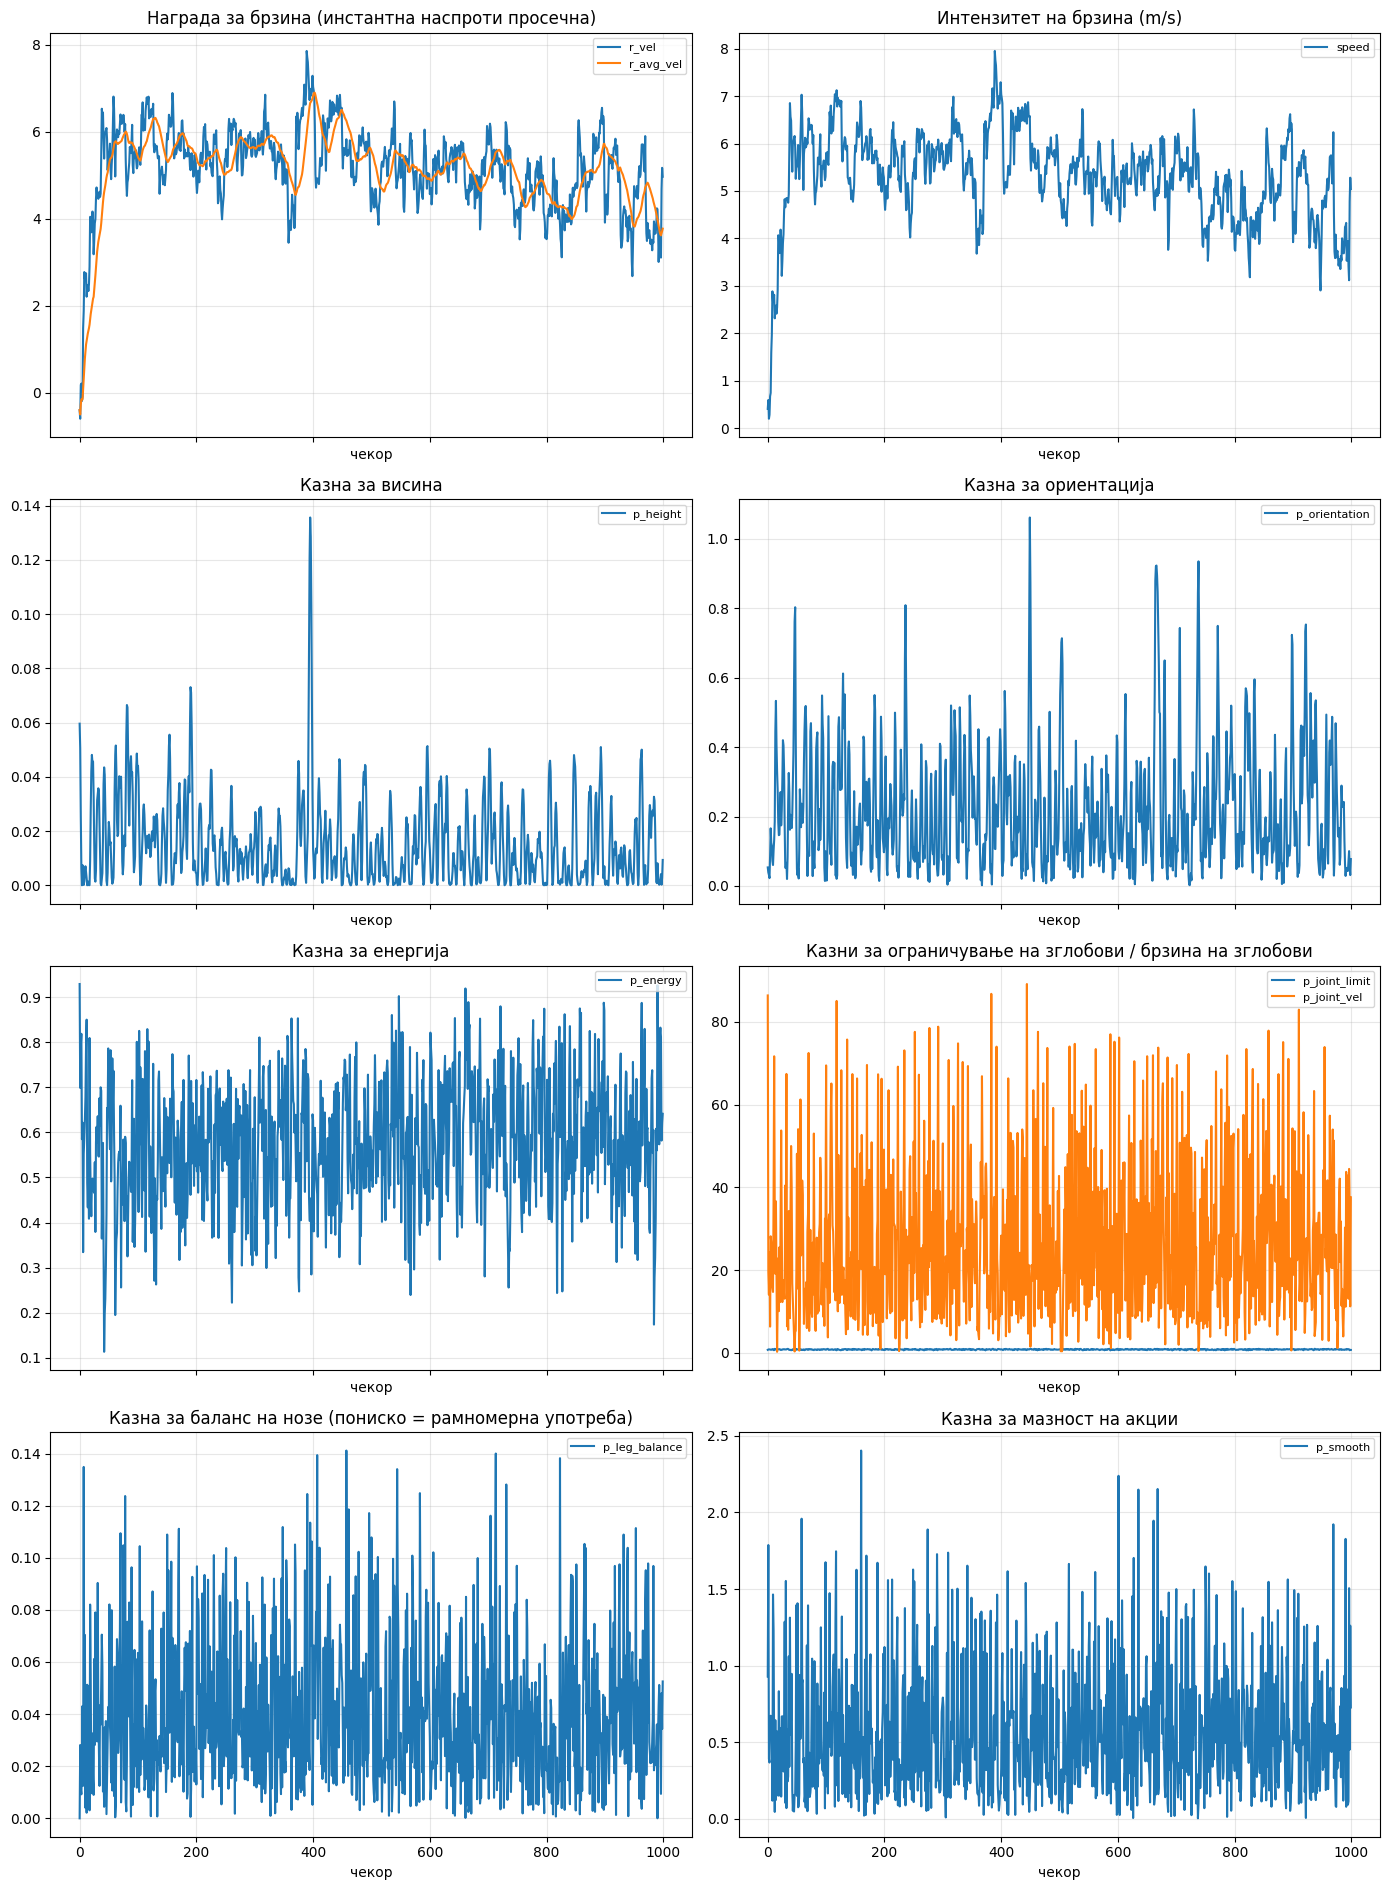

In [17]:
fig, axes = plt.subplots(4, 2, figsize=(14, 19), sharex=True)
axes = axes.flatten()

# Преведени наслови и отстранет 'p_idle'
plot_specs = [
    (["r_vel", "r_avg_vel"], "Награда за брзина (инстантна наспроти просечна)"),
    (["speed"], "Интензитет на брзина (m/s)"),
    (["p_height"], "Казна за висина"),
    (["p_orientation"], "Казна за ориентација"),
    (["p_energy"], "Казна за енергија"),
    (["p_joint_limit", "p_joint_vel"], "Казни за ограничување на зглобови / брзина на зглобови"),
    (["p_leg_balance"], "Казна за баланс на нозе (пониско = рамномерна употреба)"),
    (["p_smooth"], "Казна за мазност на акции"),
    (["total_reward"], "Вкупна награда по чекор"),
]

for ax, (cols, title) in zip(axes, plot_specs):
    for c in cols:
        ax.plot(df.index, df[c], label=c, linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("чекор")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Употреба на нозе



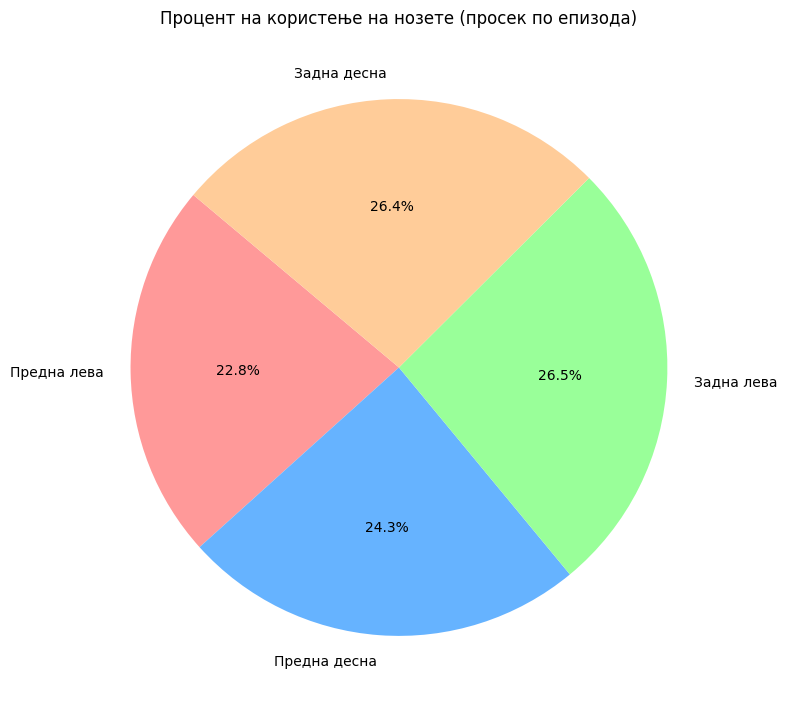

Средно користење по нога:
leg_usage_front_left     0.526894
leg_usage_front_right    0.562345
leg_usage_back_left      0.612458
leg_usage_back_right     0.610942
dtype: float64


In [18]:
# Пресметување на просечното користење за секоја нога
leg_cols = ["leg_usage_front_left", "leg_usage_front_right", "leg_usage_back_left", "leg_usage_back_right"]
means = df[leg_cols].mean()

# Преведени имиња за ознаките на дијаграмот
labels = ["Предна лева", "Предна десна", "Задна лева", "Задна десна"]

fig, ax = plt.subplots(figsize=(8, 8))

# Креирање на пита дијаграмот
ax.pie(means, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])

ax.set_title("Процент на користење на нозете (просек по епизода)")

plt.tight_layout()
plt.show()

# Печатење на вредностите во конзолата (за проверка)
print("Средно користење по нога:")
print(means)

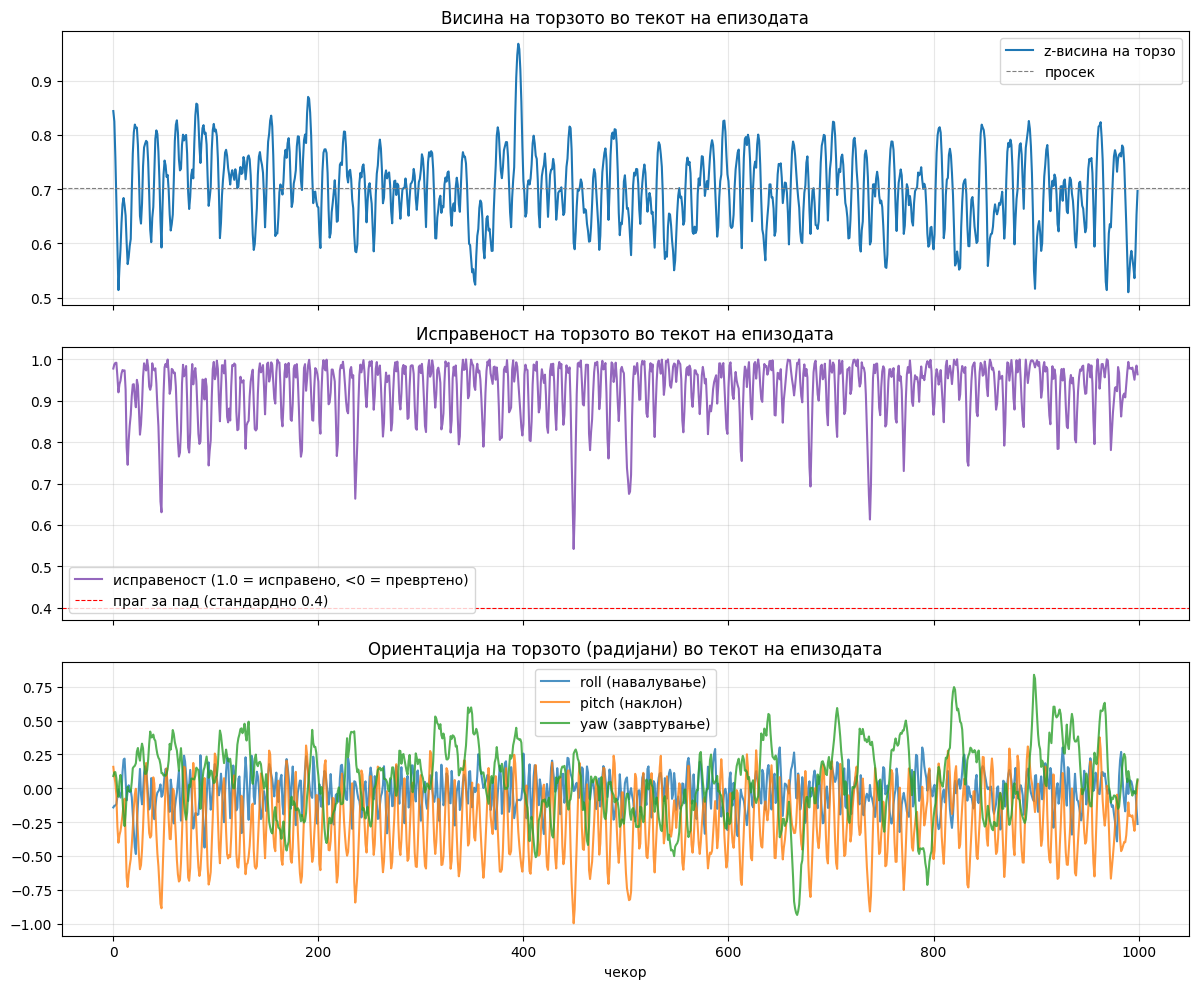

In [20]:


# Падови и траекторија на позата (висина, исправеност, ротација)
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. Висина на торзото
axes[0].plot(df.index, df["z_height"], label="z-висина на торзо", color="tab:blue")
axes[0].axhline(y=df["z_height"].mean(), color="gray", linestyle="--", linewidth=0.8, label="просек")
fall_steps = df.index[df["p_fall"] > 0]
if len(fall_steps):
    axes[0].scatter(fall_steps, df.loc[fall_steps, "z_height"], color="red", zorder=5, label="откриен пад")
axes[0].set_title("Висина на торзото во текот на епизодата")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Исправеност
axes[1].plot(df.index, df["uprightness"], label="исправеност (1.0 = исправено, <0 = превртено)", color="tab:purple")
axes[1].axhline(y=0.4, color="red", linestyle="--", linewidth=0.8, label="праг за пад (стандардно 0.4)")
axes[1].set_title("Исправеност на торзото во текот на епизодата")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Ориентација (Roll, Pitch, Yaw)
axes[2].plot(df.index, df["roll"], label="roll (навалување)", alpha=0.8)
axes[2].plot(df.index, df["pitch"], label="pitch (наклон)", alpha=0.8)
axes[2].plot(df.index, df["yaw"], label="yaw (завртување)", alpha=0.8)
axes[2].set_title("Ориентација на торзото (радијани) во текот на епизодата")
axes[2].set_xlabel("чекор")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Евалуација врз основа на повеќе епизоди



In [21]:
N_EPISODES = 10

epizoda_rezime = []
eval_env = make_ant_env()

for ep in range(N_EPISODES):
    obs, info = eval_env.reset(seed=SEED + ep)
    ep_nagrada = 0.0
    ep_dolzhina = 0
    padnal = False
    zastoj = False
    for step in range(N_EVAL_STEPS):
        action, _ = model.predict(obs, deterministic=DETERMINISTIC_POLICY)
        obs, reward, terminated, truncated, info = eval_env.step(action)
        ep_nagrada += reward
        ep_dolzhina += 1
        
        # Проверка за пад или застој
        if info["reward_components"]["p_fall"] > 0:
            padnal = True
        if info["reward_components"]["p_idle"] > 0:
            zastoj = True
            
        if terminated or truncated:
            break
            
    epizoda_rezime.append({
        "epizoda": ep, 
        "vkupna_nagrada": ep_nagrada, 
        "dolzhina": ep_dolzhina,
        "padnal": padnal, 
        "zastoj": zastoj,
    })

eval_env.close()

# Креирање на табела со резултатите
rezime_df = pd.DataFrame(epizoda_rezime)
display(rezime_df)

# Печатење на статистиката
print(f"Просечна награда: {rezime_df['vkupna_nagrada'].mean():.2f} +/- {rezime_df['vkupna_nagrada'].std():.2f}")
print(f"Просечна должина на епизода: {rezime_df['dolzhina'].mean():.1f}")
print(f"Стапка на паѓање: {rezime_df['padnal'].mean() * 100:.1f}%")
print(f"Стапка на застој: {rezime_df['zastoj'].mean() * 100:.1f}%")

,epizoda,vkupna_nagrada,dolzhina,padnal,zastoj
0,0,6555.416970,1000,False,False
1,1,6253.210829,1000,False,False
2,2,6117.423095,1000,False,False
3,3,5967.284826,1000,False,False
4,4,6698.385497,1000,False,False
5,5,6203.708705,1000,False,False
6,6,6306.081004,1000,False,False
7,7,6534.896130,1000,False,False
8,8,2256.950166,359,True,False
9,9,6825.230086,1000,False,False


Просечна награда: 5971.86 +/- 1332.50
Просечна должина на епизода: 935.9
Стапка на паѓање: 10.0%
Стапка на застој: 0.0%
